<a href="https://colab.research.google.com/github/joao-victor-g-dev/analise-ids-cicids2017/blob/main/Minera%C3%A7%C3%A3o_DataSet_CIC_IDS_2017_QUINTA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MÓDULO 01: MONTAGEM DO DRIVE E EXTRAÇÃO

In [ ]:
# ==========================================
# MÓDULO 01: MONTAGEM DO DRIVE E EXTRAÇÃO
# ==========================================
from google.colab import drive
import os
import zipfile

# 1. Montar o Google Drive
drive.mount('/content/drive')

# 2. Caminhos do diretório
zip_path = '/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/CSV/MachineLearningCSV.zip'
extract_path = '/content/dataset_csv'

print("🔍 Verificando integridade dos dados locais...")

# 3. Verificação Inteligente: Checa se a pasta tem arquivos CSV dentro
precisa_extrair = True
if os.path.exists(extract_path):
    # Conta quantos arquivos .csv existem em toda a árvore da pasta
    csv_encontrados = sum(1 for _, _, files in os.walk(extract_path) for f in files if f.endswith('.csv'))
    if csv_encontrados > 0:
        precisa_extrair = False
        print(f"✅ Diretório íntegro! Foram encontrados {csv_encontrados} arquivos CSV. Extração pulada.")
    else:
        print("⚠️ A pasta existe, mas está VAZIA. Forçando nova extração...")

# 4. Extração (se necessária)
if precisa_extrair:
    os.makedirs(extract_path, exist_ok=True)
    print("⏳ Iniciando a extração do ZIP (isso pode levar de 1 a 3 minutos)...")
    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print("✅ Dataset extraído com sucesso para o armazenamento local!")
    except Exception as e:
        print(f"❌ Erro ao tentar extrair o arquivo: {e}")
        print("Verifique se o caminho do arquivo .zip está 100% correto.")

Mounted at /content/drive
🔍 Verificando integridade dos dados locais...
⏳ Iniciando a extração do ZIP (isso pode levar de 1 a 3 minutos)...
✅ Dataset extraído com sucesso para o armazenamento local!


# MÓDULO 02: ANÁLISE EXPLORATÓRIA DE DADOS (EDA)

🔍 Buscando o arquivo da Quinta-feira (Web Attacks)...
⏳ Carregando dados da Quinta-feira...
✅ Dados carregados e limpos! Total de instâncias: 170231

🎨 Gerando Painel de Visualização Estatística (Ataques Web)...


/tmp/ipykernel_14973/3362961.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Label', palette='flare', ax=axes[0], edgecolor='black')
/tmp/ipykernel_14973/3362961.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='Average Packet Size', palette='Set2', ax=axes[1])


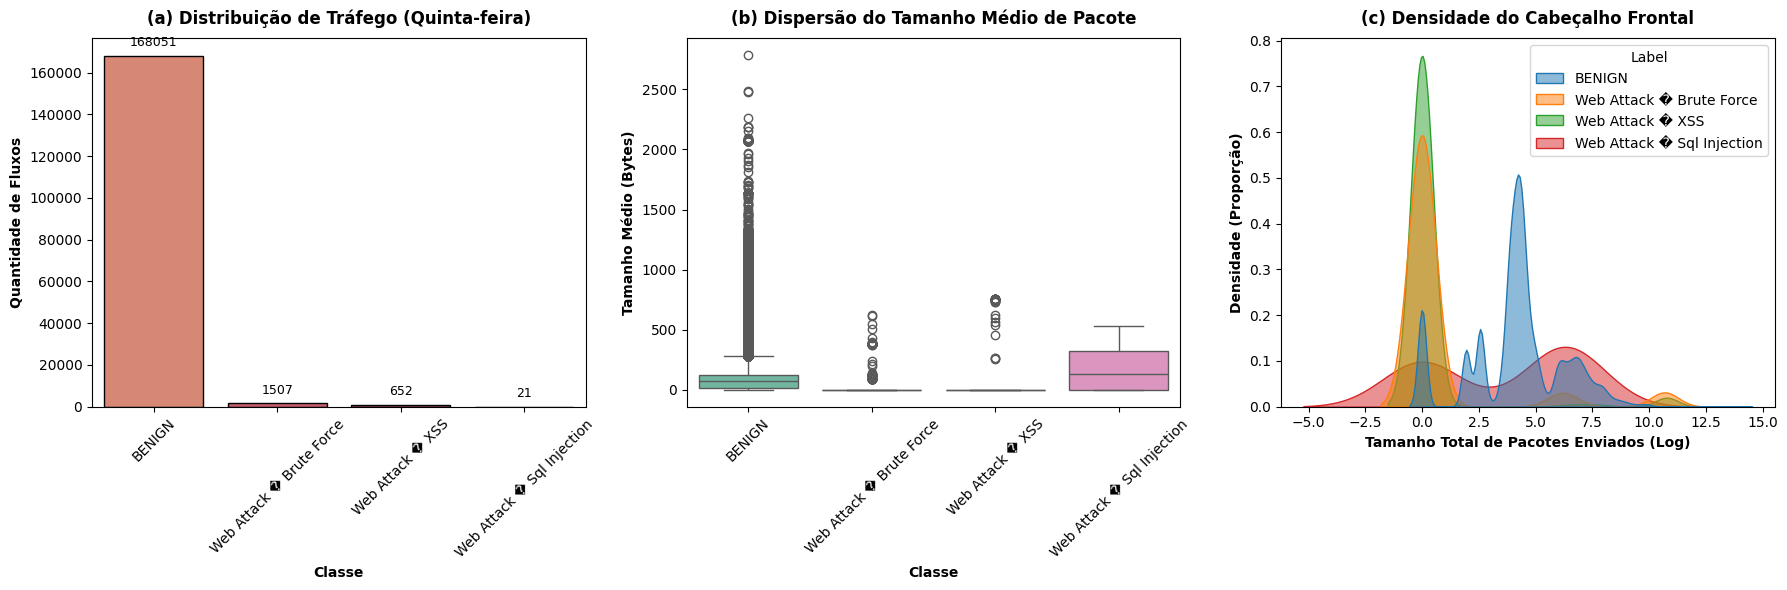

✅ Painel EDA exportado com sucesso para: /content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/graphics/EDA/painel_eda_Quinta_WebAttacks.pdf


In [ ]:
# ==========================================
# MÓDULO 02 (QUINTA-FEIRA): ANÁLISE EXPLORATÓRIA (EDA)
# Foco: Ataques Web (Força Bruta Web, XSS, SQL Injection)
# ==========================================
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Parâmetros - Ajustados para Quinta-feira (Manhã)
ARQUIVO_ALVO = 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv'
NOME_EXPERIMENTO = 'Quinta_WebAttacks'
EXTRACT_PATH = '/content/dataset_csv'
DIRETORIO_GRAFICOS = '/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/graphics/EDA'

os.makedirs(DIRETORIO_GRAFICOS, exist_ok=True)

# 2. Busca Inteligente do Arquivo
print("🔍 Buscando o arquivo da Quinta-feira (Web Attacks)...")
CAMINHO_CSV = None
for root, dirs, files in os.walk(EXTRACT_PATH):
    if ARQUIVO_ALVO in files:
        CAMINHO_CSV = os.path.join(root, ARQUIVO_ALVO)
        break

if CAMINHO_CSV is None:
    raise FileNotFoundError(f"🚨 Arquivo {ARQUIVO_ALVO} não encontrado! Verifique a extração.")

# 3. Carregamento e Limpeza
print("⏳ Carregando dados da Quinta-feira...")
df = pd.read_csv(CAMINHO_CSV)
df.columns = df.columns.str.strip()
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
print(f"✅ Dados carregados e limpos! Total de instâncias: {len(df)}")

# ==========================================
# GERAÇÃO DO PAINEL VISUAL (IEEE FORMAT)
# ==========================================
print("\n🎨 Gerando Painel de Visualização Estatística (Ataques Web)...")
plt.rcParams['font.family'] = 'sans-serif'
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Gráfico 1: Distribuição de Classes ---
sns.countplot(data=df, x='Label', palette='flare', ax=axes[0], edgecolor='black')
axes[0].set_title('(a) Distribuição de Tráfego (Quinta-feira)', fontweight='bold', pad=10)
axes[0].set_ylabel('Quantidade de Fluxos', fontweight='bold')
axes[0].set_xlabel('Classe', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
# Adicionar valores para vermos quão raras são essas classes
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5), textcoords='offset points')

# --- Gráfico 2: Box Plot - Tamanho Médio do Pacote ---
# Para ataques Web, o tamanho médio importa mais que o pico máximo
sns.boxplot(data=df, x='Label', y='Average Packet Size', palette='Set2', ax=axes[1])
axes[1].set_title('(b) Dispersão do Tamanho Médio de Pacote', fontweight='bold', pad=10)
axes[1].set_ylabel('Tamanho Médio (Bytes)', fontweight='bold')
axes[1].set_xlabel('Classe', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

# --- Gráfico 3: Histograma - Comprimento do Cabeçalho Frontal ---
# Ataques de injeção costumam alterar o tamanho do cabeçalho
df['Log_Fwd_Header'] = np.log1p(df['Total Length of Fwd Packets'])
sns.kdeplot(data=df, x='Log_Fwd_Header', hue='Label', fill=True, common_norm=False, palette='tab10', ax=axes[2], alpha=0.5)
axes[2].set_title('(c) Densidade do Cabeçalho Frontal', fontweight='bold', pad=10)
axes[2].set_ylabel('Densidade (Proporção)', fontweight='bold')
axes[2].set_xlabel('Tamanho Total de Pacotes Enviados (Log)', fontweight='bold')

plt.tight_layout()

# Exportação
caminho_painel = os.path.join(DIRETORIO_GRAFICOS, f'painel_eda_{NOME_EXPERIMENTO}.pdf')
plt.savefig(caminho_painel, bbox_inches='tight')
plt.show()

print(f"✅ Painel EDA exportado com sucesso para: {caminho_painel}")

# MÓDULO 03: PRÉ-PROCESSAMENTO (QUINTA-FEIRA - Web Attacks)

In [ ]:
# ==========================================
# MÓDULO 03: PRÉ-PROCESSAMENTO (QUINTA-FEIRA - Web Attacks)
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import gc
import joblib
import os

NOME_EXPERIMENTO = 'Quinta_WebAttacks'
DIRETORIO_ARTEFATOS = f'/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/artifacts/{NOME_EXPERIMENTO}'
os.makedirs(DIRETORIO_ARTEFATOS, exist_ok=True)

print("1. Removendo colunas temporárias e isolando X e y...")
if 'Log_Fwd_Header' in df.columns:
    df = df.drop(columns=['Log_Fwd_Header'])

X = df.drop(columns=['Label'])
y = df['Label']

del df
gc.collect()

print("2. Codificando as Classes (Label Encoding)...")
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
nomes_classes = label_encoder.classes_
print(f"   -> Classes mapeadas: {list(nomes_classes)}")
joblib.dump(label_encoder, os.path.join(DIRETORIO_ARTEFATOS, 'label_encoder.joblib'))

print("3. Dividindo em Treino (70%) e Teste (30%)...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)
del X, y
gc.collect()

print("4. Aplicando Normalização (StandardScaler)...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
joblib.dump(scaler, os.path.join(DIRETORIO_ARTEFATOS, 'scaler.joblib'))

del X_train, X_test
gc.collect()

print("✅ Módulo 03 Concluído! Dados prontos para a IA.")

1. Removendo colunas temporárias e isolando X e y...
2. Codificando as Classes (Label Encoding)...
   -> Classes mapeadas: ['BENIGN', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']
3. Dividindo em Treino (70%) e Teste (30%)...
4. Aplicando Normalização (StandardScaler)...
✅ Módulo 03 Concluído! Dados prontos para a IA.


# MÓDULO 04-A: TREINAMENTO RANDOM FOREST (QUINTA-FEIRA)

In [ ]:
# ==========================================
# MÓDULO 04-A: TREINAMENTO RANDOM FOREST (QUINTA-FEIRA)
# ==========================================
from sklearn.ensemble import RandomForestClassifier
import joblib
import os

NOME_EXPERIMENTO = 'Quinta_WebAttacks'
DIRETORIO_ARTEFATOS = f'/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/artifacts/{NOME_EXPERIMENTO}'

print("🤖 Iniciando o Treinamento: Random Forest...")

rf = RandomForestClassifier(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
joblib.dump(rf, os.path.join(DIRETORIO_ARTEFATOS, 'modelo_rf.joblib'))
joblib.dump(y_pred_rf, os.path.join(DIRETORIO_ARTEFATOS, 'y_pred_rf.joblib'))

print("✅ Random Forest treinado e salvo!")

🤖 Iniciando o Treinamento: Random Forest...
✅ Random Forest treinado e salvo!


# MÓDULO 04-B: TREINAMENTO HIST GRADIENT BOOSTING (QUINTA-FEIRA)

In [ ]:
# ==========================================
# MÓDULO 04-B: TREINAMENTO HIST GRADIENT BOOSTING (QUINTA-FEIRA)
# ==========================================
from sklearn.ensemble import HistGradientBoostingClassifier
import joblib
import os

NOME_EXPERIMENTO = 'Quinta_WebAttacks'
DIRETORIO_ARTEFATOS = f'/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/artifacts/{NOME_EXPERIMENTO}'

print("🤖 Iniciando o Treinamento: HistGradientBoosting...")

hgb = HistGradientBoostingClassifier(max_iter=100, learning_rate=0.1, random_state=42)
hgb.fit(X_train_scaled, y_train)

y_pred_hgb = hgb.predict(X_test_scaled)
joblib.dump(hgb, os.path.join(DIRETORIO_ARTEFATOS, 'modelo_hgb.joblib'))
joblib.dump(y_pred_hgb, os.path.join(DIRETORIO_ARTEFATOS, 'y_pred_hgb.joblib'))

print("✅ HistGradientBoosting treinado e salvo!")

🤖 Iniciando o Treinamento: HistGradientBoosting...
✅ HistGradientBoosting treinado e salvo!


# MÓDULO 05: AVALIAÇÃO DE RESULTADOS E MATRIZES (QUINTA-FEI

1. Carregando as predições e o Label Encoder...

📊 RELATÓRIO DE CLASSIFICAÇÃO (Com nomes corrigidos)

--- PERFORMANCE: RANDOM FOREST ---
                          precision    recall  f1-score   support

                  BENIGN       1.00      1.00      1.00     50416
  Web Attack-Brute Force       0.72      0.89      0.79       452
Web Attack-Sql Injection       1.00      0.50      0.67         6
          Web Attack-XSS       0.41      0.15      0.22       196

                accuracy                           1.00     51070
               macro avg       0.78      0.63      0.67     51070
            weighted avg       0.99      1.00      0.99     51070


--- PERFORMANCE: HIST GRADIENT BOOSTING ---
                          precision    recall  f1-score   support

                  BENIGN       1.00      1.00      1.00     50416
  Web Attack-Brute Force       0.63      0.71      0.67       452
Web Attack-Sql Injection       0.04      0.50      0.08         6
          Web Attack-X

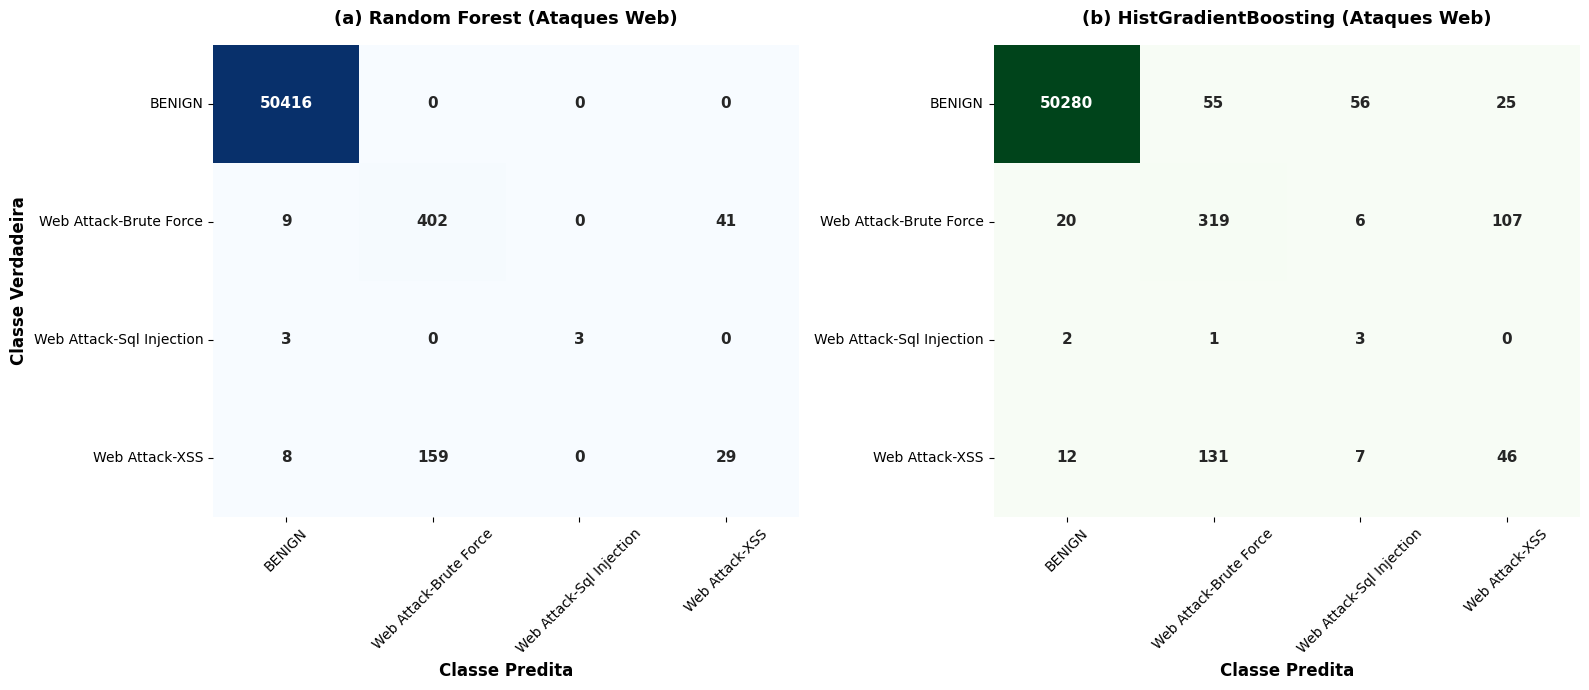

✅ Gráfico exportado sem bugs de texto para: /content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/graphics/matrizes_confusao_Quinta_WebAttacks.pdf


In [ ]:
# ==========================================
# MÓDULO 05: AVALIAÇÃO DE RESULTADOS (COM CORREÇÃO DE TEXTO E HGB)
# ==========================================
import os
import joblib
import re
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

NOME_EXPERIMENTO = 'Quinta_WebAttacks'
DIRETORIO_ARTEFATOS = f'/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/artifacts/{NOME_EXPERIMENTO}'
DIRETORIO_GRAFICOS = '/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/graphics'

print("1. Carregando as predições e o Label Encoder...")
label_encoder = joblib.load(os.path.join(DIRETORIO_ARTEFATOS, 'label_encoder.joblib'))

# CORREÇÃO DO BUG DO DATASET CIC-IDS-2017 (Limpando caracteres estranhos)
nomes_classes_originais = label_encoder.classes_
nomes_classes_limpos = [re.sub(r'[^\x00-\x7F]+', '-', str(nome)) for nome in nomes_classes_originais]
# Ajuste fino extra caso fique com dois espaços
nomes_classes_limpos = [nome.replace(' - ', '-') for nome in nomes_classes_limpos]

y_pred_rf = joblib.load(os.path.join(DIRETORIO_ARTEFATOS, 'y_pred_rf.joblib'))
y_pred_hgb = joblib.load(os.path.join(DIRETORIO_ARTEFATOS, 'y_pred_hgb.joblib'))

print("\n" + "="*60)
print(f"📊 RELATÓRIO DE CLASSIFICAÇÃO (Com nomes corrigidos)")
print("="*60)

# Relatório do Random Forest
print("\n--- PERFORMANCE: RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf, target_names=nomes_classes_limpos))

# Relatório do Hist Gradient Boosting (ADICIONADO)
print("\n--- PERFORMANCE: HIST GRADIENT BOOSTING ---")
print(classification_report(y_test, y_pred_hgb, target_names=nomes_classes_limpos))

print("\n2. Renderizando painel de Matrizes de Confusão...")
plt.rcParams['font.family'] = 'sans-serif'
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Matriz 1: Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1,
            xticklabels=nomes_classes_limpos, yticklabels=nomes_classes_limpos, annot_kws={"weight": "bold", "size": 11})
ax1.set_title('(a) Random Forest (Ataques Web)', fontweight='bold', pad=15, fontsize=13)
ax1.set_ylabel('Classe Verdadeira', fontweight='bold', fontsize=12)
ax1.set_xlabel('Classe Predita', fontweight='bold', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# Matriz 2: HistGradientBoosting
cm_hgb = confusion_matrix(y_test, y_pred_hgb)
sns.heatmap(cm_hgb, annot=True, fmt='d', cmap='Greens', cbar=False, ax=ax2,
            xticklabels=nomes_classes_limpos, yticklabels=nomes_classes_limpos, annot_kws={"weight": "bold", "size": 11})
ax2.set_title('(b) HistGradientBoosting (Ataques Web)', fontweight='bold', pad=15, fontsize=13)
ax2.set_ylabel('')
ax2.set_xlabel('Classe Predita', fontweight='bold', fontsize=12)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()

caminho_saida = os.path.join(DIRETORIO_GRAFICOS, f'matrizes_confusao_{NOME_EXPERIMENTO}.pdf')
plt.savefig(caminho_saida, bbox_inches='tight')
plt.show()

print(f"✅ Gráfico exportado sem bugs de texto para: {caminho_saida}")